In [1]:
# %%
import sys, importlib
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("sys.path[0]:", sys.path[0])
print("Python executable:", sys.executable)

importlib.invalidate_caches()

import src
print("src module file:", src.__file__)

from src import data_loader
print("data_loader loaded:", data_loader.__file__)

sys.path[0]: C:\mule-account-detection
Python executable: c:\Users\Vivek\anaconda3\python.exe
src module file: C:\mule-account-detection\src\__init__.py
data_loader loaded: C:\mule-account-detection\src\data_loader.py


In [2]:
# %%
from pathlib import Path

src_dir = Path.cwd().resolve().parent / "src"
for f in src_dir.iterdir():
    print(repr(f.name))

'config.py'
'data_loader.py'
'evaluate.py'
'explainability.py'
'feature_triage.py'
'linkage_graph.py'
'modeling'
'preprocessing.py'
'report_generator.py'
'__init__.py'


In [2]:
# %%
X, y = data_loader.load_dataset()

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())
print("Positive rate: {:.2%}".format(y.mean()))

X shape: (9082, 3923)
y distribution:
 F3924
0    9001
1      81
Name: count, dtype: int64
Positive rate: 0.89%


In [3]:
# %%
import pandas as pd

# ---- Target imbalance ----
print("=== Target Distribution ===")
print(y.value_counts())
print(f"Positive (mule) rate: {y.mean():.4%}\n")

# ---- Missingness ----
missing_ratio = X.isnull().mean().sort_values(ascending=False)

print("=== Missingness Summary ===")
print(f"Total columns: {X.shape[1]}")
print(f"Columns >90% missing: {(missing_ratio > 0.90).sum()}")
print(f"Columns >50% missing: {(missing_ratio > 0.50).sum()}")
print(f"Columns with 0% missing: {(missing_ratio == 0).sum()}\n")

print("Top 10 most-missing columns:")
print(missing_ratio.head(10))

# ---- Categorical columns ----
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print("\n=== Categorical Columns ===")
print(cat_cols)

for c in cat_cols:
    print(f"\n{c} -> unique values: {X[c].unique().tolist()}")

=== Target Distribution ===
F3924
0    9001
1      81
Name: count, dtype: int64
Positive (mule) rate: 0.8919%

=== Missingness Summary ===
Total columns: 3923
Columns >90% missing: 516
Columns >50% missing: 1138
Columns with 0% missing: 88

Top 10 most-missing columns:
F3776    1.0
F3773    1.0
F3133    1.0
F2607    1.0
F2655    1.0
F539     1.0
F542     1.0
F437     1.0
F2753    1.0
F440     1.0
dtype: float64

=== Categorical Columns ===
['F2230', 'F3886', 'F3888', 'F3889', 'F3890', 'F3891', 'F3892', 'F3893']

F2230 -> unique values: ['Oct25', 'Sep25', 'Nov25', 'Dec25']

F3886 -> unique values: ['Savings', 'Current', 'MSME Micro', 'MSME Medium', 'Corp Adv', 'MSME Small', 'Agri Adv', 'Retail LA TDR', 'Staff Loans', 'ML', 'HL', 'Retail Others', 'PL', 'All Others', 'MSME LA TDR', 'Gold Loan', 'Term Deposit']

F3888 -> unique values: ['8-1-2011', '8-2-2011', '8-4-2011', '8-8-2011', '8-10-2011', '8-11-2011', '8-16-2011', '8-17-2011', '8-19-2011', '8-20-2011', '8-23-2011', '8-24-2011', '9-

In [2]:
# %%
from pathlib import Path
fp = Path.cwd().resolve().parent / "src" / "feature_triage.py"
print(fp.exists())
print(fp.read_text()[:200])  # first 200 chars - should show "import json..."

True
import json
import time
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.preprocessing import LabelEncoder
from xgboost 


In [1]:
# %%
from src.feature_triage import select_top_features, save_selected_features

top_features = select_top_features(X, y)
save_selected_features(top_features)

print(top_features[:20])

ModuleNotFoundError: No module named 'src.feature_triage'

In [1]:
# %%
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import data_loader

In [2]:
# %%
X, y = data_loader.load_dataset()
print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

X shape: (9082, 3923)
y distribution:
 F3924
0    9001
1      81
Name: count, dtype: int64


In [3]:
# %%
from src.feature_triage import select_top_features, save_selected_features

top_features = select_top_features(X, y)
save_selected_features(top_features)

print(top_features[:20])

Dropping 516 columns (> 90% missing)
Dropping 281 zero-variance columns
Computing mutual information (this is the slow step)...
Mutual info done in 220.6s
Training XGBoost for importance ranking...
XGBoost done in 17.5s
Selected top 80 features (from 3923 original).
Saved selected features to C:\mule-account-detection\outputs\selected_features.json
['F3912', 'F2230', 'F1057', 'F3898', 'F1165', 'F2486', 'F3799', 'F2030', 'F1813', 'F3806', 'F2686', 'F3598', 'F162', 'F1166', 'F2036', 'F2684', 'F2390', 'F1922', 'F2388', 'F1926']


In [5]:
# %%
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

cat_in_top = [f for f in top_features if f in cat_cols]
print("Categorical features in top 80:", cat_in_top)

import pandas as pd
df_check = X[top_features[:5]].copy()
df_check["target"] = y.values
print(df_check.groupby("target").mean(numeric_only=True))

Categorical features in top 80: ['F2230']
           F3912         F1057     F3898         F1165
target                                                
0       0.000333  7.141693e+06  1.867348  8.881233e+06
1       0.975309  1.009015e+05  0.617284  1.237779e+05


In [6]:
# %%
# How many of the top 80 are categorical?
cat_in_top = [f for f in top_features if f in cat_cols]
print("Categorical features in top 80:", cat_in_top)

# How does the target relate to a few top features? Quick sanity check
import pandas as pd
df_check = X[top_features[:5]].copy()
df_check["target"] = y.values
print(df_check.groupby("target").mean(numeric_only=True))

Categorical features in top 80: ['F2230']
           F3912         F1057     F3898         F1165
target                                                
0       0.000333  7.141693e+06  1.867348  8.881233e+06
1       0.975309  1.009015e+05  0.617284  1.237779e+05


In [7]:
# %%
import json
from src.preprocessing import fit_transform_features, save_pipeline

with open("../outputs/selected_features.json") as f:
    selected_features = json.load(f)

X_processed, pipeline, feature_names = fit_transform_features(X, selected_features)

print("X_processed shape:", X_processed.shape)
print("Number of output feature names:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

save_pipeline(pipeline)

X_processed shape: (9082, 83)
Number of output feature names: 83
First 10 feature names: ['F1057', 'F1063', 'F1069', 'F1165', 'F1166', 'F1177', 'F1273', 'F1321', 'F1323', 'F1381']
Saved preprocessing pipeline to C:\mule-account-detection\models\preprocessor.pkl


In [8]:
# %%
missing_in_selected = X[selected_features].isnull().mean().sort_values(ascending=False)
print("Missingness in selected 80 features:")
print(missing_in_selected.describe())
print("\nTop 10 most-missing among selected:")
print(missing_in_selected.head(10))

Missingness in selected 80 features:
count    80.000000
mean      0.090476
std       0.189452
min       0.000000
25%       0.000440
50%       0.000991
75%       0.043465
max       0.810284
dtype: float64

Top 10 most-missing among selected:
F478     0.810284
F193     0.779894
F306     0.714710
F58      0.626844
F2486    0.368641
F2686    0.362475
F2390    0.362475
F2380    0.360273
F267     0.359943
F162     0.359612
dtype: float64


In [9]:
# %%
missing_in_selected = X[selected_features].isnull().mean().sort_values(ascending=False) \
    if 'selected_features' in dir() else X[top_features].isnull().mean().sort_values(ascending=False)

print("Missingness in selected 80 features:")
print(missing_in_selected.describe())
print("\nTop 10 most-missing among selected:")
print(missing_in_selected.head(10))

Missingness in selected 80 features:
count    80.000000
mean      0.090476
std       0.189452
min       0.000000
25%       0.000440
50%       0.000991
75%       0.043465
max       0.810284
dtype: float64

Top 10 most-missing among selected:
F478     0.810284
F193     0.779894
F306     0.714710
F58      0.626844
F2486    0.368641
F2686    0.362475
F2390    0.362475
F2380    0.360273
F267     0.359943
F162     0.359612
dtype: float64


In [ ]:
# %%
import json
from src.preprocessing import fit_transform_features, save_pipeline

with open("../outputs/selected_features.json") as f:
    selected_features = json.load(f)

X_processed, pipeline, feature_names = fit_transform_features(X, selected_features)

print("X_processed shape:", X_processed.shape)
print("Number of output feature names:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

save_pipeline(pipeline)     

X_processed shape: (9082, 83)
Number of output feature names: 83
First 10 feature names: ['F1057', 'F1063', 'F1069', 'F1165', 'F1166', 'F1177', 'F1273', 'F1321', 'F1323', 'F1381']
Saved preprocessing pipeline to C:\mule-account-detection\models\preprocessor.pkl


In [11]:
# %%
from src.modeling.supervised import train_cv, evaluate_predictions, train_final_model, save_model

oof_preds, fold_models = train_cv(X_processed, y)

print("\n=== Cross-Validated Performance (5-fold) ===")
evaluate_predictions(y, oof_preds)

final_model = train_final_model(X_processed, y)
save_model(final_model)

Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.

=== Cross-Validated Performance (5-fold) ===
PR-AUC: 1.0000
ROC-AUC: 1.0000
Precision @ 0.5: 1.0000
Recall @ 0.5: 1.0000
F1 @ 0.5: 1.0000

Confusion Matrix:
[[9001    0]
 [   0   81]]
Saved model to C:\mule-account-detection\models\xgb_model.pkl


In [12]:
# %%
import json
with open("../outputs/selected_features.json") as f:
    selected_features = json.load(f)

# Check correlation of each selected feature with the target
correlations = X[selected_features].apply(
    lambda col: pd.to_numeric(col, errors='coerce')
).corrwith(y).abs().sort_values(ascending=False)

print("Top correlated features with target:")
print(correlations.head(10))

Top correlated features with target:
F3912    0.969066
F267     0.105331
F2686    0.097861
F3908    0.097022
F162     0.077092
F3534    0.059313
F228     0.056711
F3898    0.054760
F58      0.050393
F1926    0.050339
dtype: float64


In [13]:
# %%
print(X["F3912"].describe())
print("\nUnique values:", X["F3912"].unique()[:20])
print("\nCrosstab with target:")
print(pd.crosstab(X["F3912"], y))


count    9082.000000
mean        0.009029
std         0.094596
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: F3912, dtype: float64

Unique values: [0 1]

Crosstab with target:
F3924     0   1
F3912          
0      8998   2
1         3  79


In [1]:
# %%
import sys
from pathlib import Path
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import data_loader
X, y = data_loader.load_dataset()
print("X shape (should now be one less column):", X.shape)

X shape (should now be one less column): (9082, 3922)


In [2]:
# %%
from src.feature_triage import select_top_features, save_selected_features

top_features = select_top_features(X, y)
save_selected_features(top_features)
print(top_features[:20])

Dropping 516 columns (> 90% missing)
Dropping 281 zero-variance columns
Computing mutual information (this is the slow step)...
Mutual info done in 199.6s
Training XGBoost for importance ranking...
XGBoost done in 8.8s
Selected top 80 features (from 3922 original).
Saved selected features to C:\mule-account-detection\outputs\selected_features.json
['F2230', 'F3805', 'F3898', 'F2489', 'F949', 'F270', 'F1057', 'F1813', 'F2138', 'F3640', 'F2137', 'F1921', 'F1166', 'F3913', 'F3908', 'F2388', 'F3105', 'F3899', 'F2999', 'F2487']


In [4]:
# %%
import pandas as pd
import json

with open("../outputs/selected_features.json") as f:
    top_features = json.load(f)

correlations = X[top_features].apply(
    lambda col: pd.to_numeric(col, errors='coerce')
).corrwith(y).abs().sort_values(ascending=False)

print("Top correlated features with target:")
print(correlations.head(10))

Top correlated features with target:
F267     0.105331
F3908    0.097022
F270     0.090042
F996     0.066574
F3640    0.064773
F1428    0.063339
F3913    0.063235
F3532    0.063034
F3898    0.054760
F2486    0.047328
dtype: float64


In [5]:
# %%
from src.preprocessing import fit_transform_features, save_pipeline

X_processed, pipeline, feature_names = fit_transform_features(X, top_features)

print("X_processed shape:", X_processed.shape)
save_pipeline(pipeline)

X_processed shape: (9082, 83)
Saved preprocessing pipeline to C:\mule-account-detection\models\preprocessor.pkl


In [6]:
# %%
from src.modeling.supervised import train_cv, evaluate_predictions, train_final_model, save_model

oof_preds, fold_models = train_cv(X_processed, y)

print("\n=== Cross-Validated Performance (5-fold) ===")
evaluate_predictions(y, oof_preds)

final_model = train_final_model(X_processed, y)
save_model(final_model)

Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.

=== Cross-Validated Performance (5-fold) ===
PR-AUC: 1.0000
ROC-AUC: 1.0000
Precision @ 0.5: 1.0000
Recall @ 0.5: 1.0000
F1 @ 0.5: 1.0000

Confusion Matrix:
[[9001    0]
 [   0   81]]
Saved model to C:\mule-account-detection\models\xgb_model.pkl


In [7]:
# %%
print(pd.crosstab(X["F3913"], y))

F3924     0   1
F3913          
0      3787  61
1      5214  20


In [8]:
# %%
print("Total rows:", len(X))
print("Unique rows:", X.drop_duplicates().shape[0])
print("Duplicate target rows for mules:", X[y==1].duplicated().sum())

Total rows: 9082
Unique rows: 9082
Duplicate target rows for mules: 0


In [9]:
# %%
importances = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.head(10))

F2230_Oct25    1.0
F1063          0.0
F1057          0.0
F1166          0.0
F1171          0.0
F1177          0.0
F1179          0.0
F1215          0.0
F1273          0.0
F1285          0.0
dtype: float32


In [10]:
# %%
top_feat = importances.index[0]
print(top_feat)
print(pd.crosstab(X[top_feat], y))

F2230_Oct25


KeyError: 'F2230_Oct25'

In [11]:
# %%
print(pd.crosstab(X["F2230"], y))

F3924     0   1
F2230          
Dec25     0  10
Nov25     0  23
Oct25  9001   0
Sep25     0  48


In [1]:
# %%
import sys
from pathlib import Path
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import data_loader
X, y = data_loader.load_dataset()
print("X shape:", X.shape)

X shape: (9082, 3921)


In [2]:
# %%
from src.feature_triage import select_top_features, save_selected_features

top_features = select_top_features(X, y)
save_selected_features(top_features)
print(top_features[:20])

Dropping 516 columns (> 90% missing)
Dropping 281 zero-variance columns
Computing mutual information (this is the slow step)...
Mutual info done in 200.3s
Training XGBoost for importance ranking...
XGBoost done in 13.2s
Selected top 80 features (from 3921 original).
Saved selected features to C:\mule-account-detection\outputs\selected_features.json
['F3898', 'F3805', 'F1597', 'F270', 'F3811', 'F2030', 'F1057', 'F1705', 'F1814', 'F3484', 'F1495', 'F2390', 'F949', 'F996', 'F2489', 'F2138', 'F1921', 'F955', 'F3812', 'F3800']


In [3]:
# %%
import pandas as pd
correlations = X[top_features].apply(
    lambda col: pd.to_numeric(col, errors='coerce')
).corrwith(y).abs().sort_values(ascending=False)
print(correlations.head(10))

F267     0.105331
F3908    0.097022
F159     0.093080
F270     0.090042
F162     0.077092
F2184    0.075783
F2076    0.075014
F1968    0.072694
F160     0.071886
F158     0.068858
dtype: float64


In [4]:
# %%
from src.preprocessing import fit_transform_features, save_pipeline
X_processed, pipeline, feature_names = fit_transform_features(X, top_features)
save_pipeline(pipeline)

Saved preprocessing pipeline to C:\mule-account-detection\models\preprocessor.pkl


In [5]:
# %%
from src.modeling.supervised import train_cv, evaluate_predictions, train_final_model, save_model
oof_preds, fold_models = train_cv(X_processed, y)
print("\n=== Cross-Validated Performance (5-fold) ===")
evaluate_predictions(y, oof_preds)
final_model = train_final_model(X_processed, y)
save_model(final_model)

Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.

=== Cross-Validated Performance (5-fold) ===
PR-AUC: 0.8932
ROC-AUC: 0.9819
Precision @ 0.5: 0.8375
Recall @ 0.5: 0.8272
F1 @ 0.5: 0.8323

Confusion Matrix:
[[8988   13]
 [  14   67]]
Saved model to C:\mule-account-detection\models\xgb_model.pkl


In [6]:
# %%
from src.modeling.supervised import evaluate_predictions
evaluate_predictions(y, oof_preds)

PR-AUC: 0.8932
ROC-AUC: 0.9819
Precision @ 0.5: 0.8375
Recall @ 0.5: 0.8272
F1 @ 0.5: 0.8323

Confusion Matrix:
[[8988   13]
 [  14   67]]


{'pr_auc': np.float64(0.8931842794700278),
 'roc_auc': np.float64(0.9818593544475854)}

In [7]:
# %%
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, oof_preds >= 0.5)
print("Confusion Matrix:")
print(cm)
print(f"\nOf 81 actual mules: caught {cm[1][1]}, missed {cm[1][0]}")
print(f"Of 9001 normal accounts: correctly cleared {cm[0][0]}, false alarms {cm[0][1]}")

Confusion Matrix:
[[8988   13]
 [  14   67]]

Of 81 actual mules: caught 67, missed 14
Of 9001 normal accounts: correctly cleared 8988, false alarms 13


In [9]:
# %%
import shap
from src.explainability import compute_shap_values, get_top_drivers, plot_summary, save_shap_values

shap_df, explainer = compute_shap_values(final_model, X_processed, feature_names)

# Show top drivers for a flagged mule account
flagged_indices = (oof_preds >= 0.5).nonzero()[0]
print(f"\nTotal flagged accounts: {len(flagged_indices)}")
print(f"\nTop drivers for flagged account #{flagged_indices[0]}:")
drivers = get_top_drivers(shap_df, flagged_indices[0], top_n=5)
for d in drivers:
    print(f"  {d['feature']}: {d['shap_value']} ({d['direction']})")

plot_summary(shap_df, X_processed, feature_names)
save_shap_values(shap_df)

Computing SHAP values...
SHAP values computed for 9082 accounts.

Total flagged accounts: 80

Top drivers for flagged account #206:
  F3898: 1.2273000478744507 (↑ risk)
  F3908: 0.8176000118255615 (↑ risk)
  F3700: -0.8069999814033508 (↓ risk)
  F2489: 0.680400013923645 (↑ risk)
  F160: -0.5709999799728394 (↓ risk)
SHAP summary plot saved to C:\mule-account-detection\outputs\shap_summary.png
SHAP values saved to C:\mule-account-detection\outputs\shap_values.csv


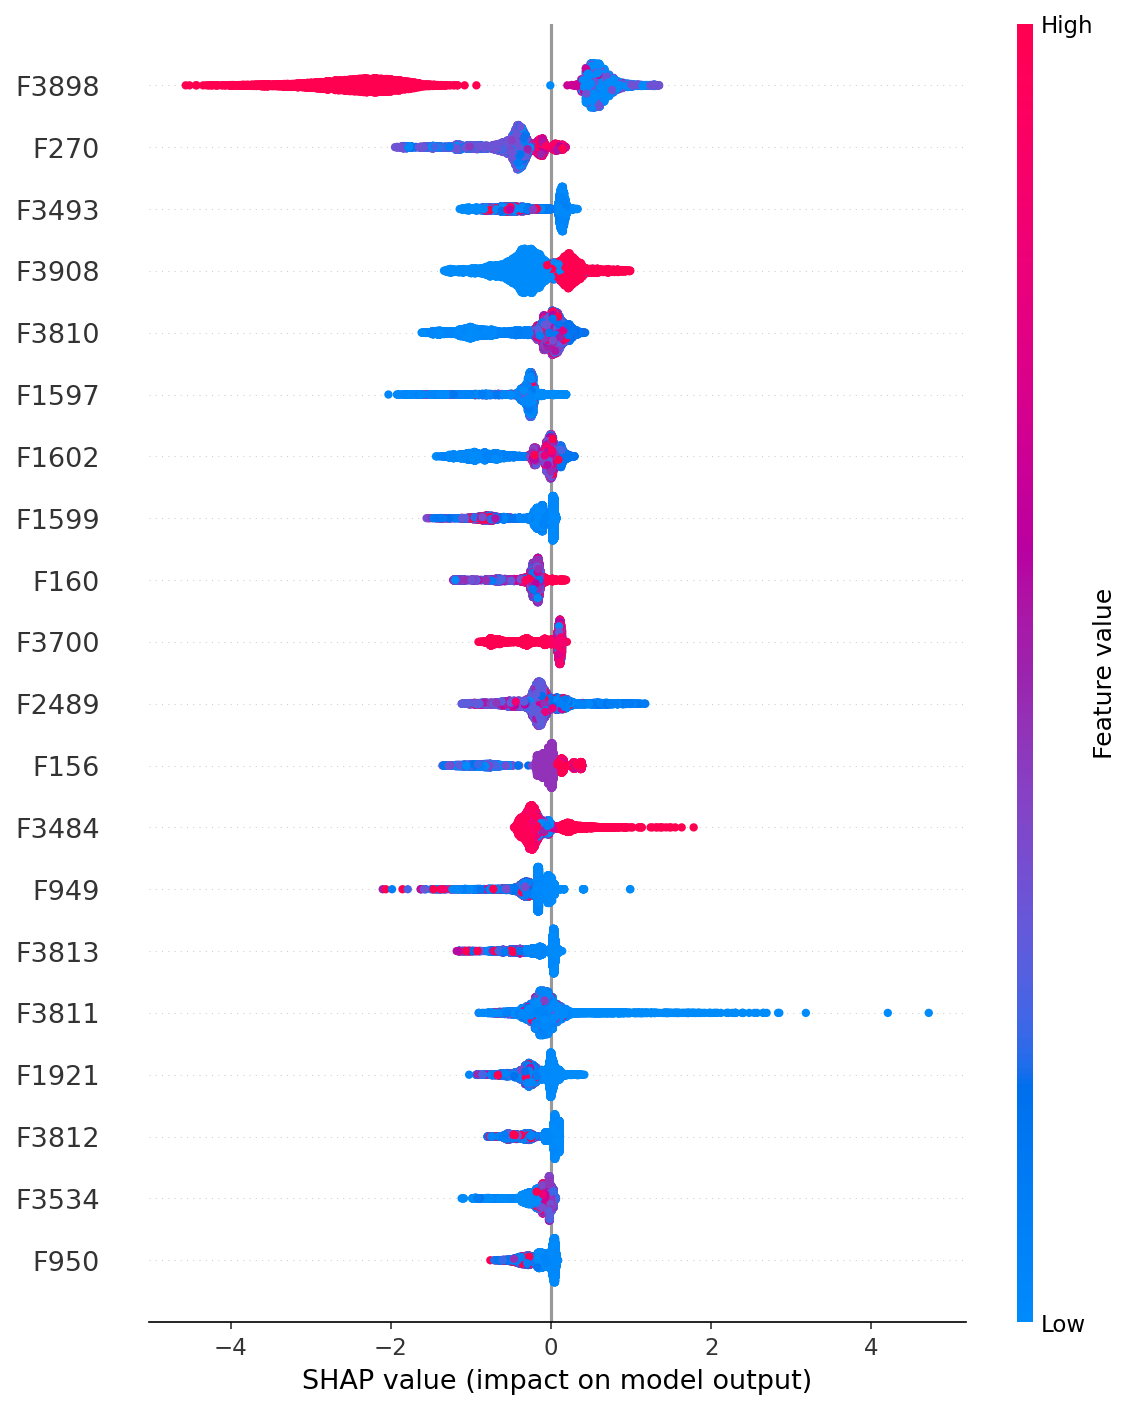

In [10]:
# %%
from IPython.display import Image
Image("../outputs/shap_summary.png")

In [11]:
# %%
from src.modeling.unsupervised import train_isolation_forest, get_anomaly_scores, save_iso_model

iso_model = train_isolation_forest(X_processed)
anomaly_scores = get_anomaly_scores(iso_model, X_processed)

print("Anomaly score stats:")
print(pd.Series(anomaly_scores).describe())
print(f"\nMean anomaly score for mules: {anomaly_scores[y==1].mean():.4f}")
print(f"Mean anomaly score for normals: {anomaly_scores[y==0].mean():.4f}")

save_iso_model(iso_model)

Training Isolation Forest (contamination=0.0089)...
Isolation Forest trained.
Anomaly score stats:
count    9082.000000
mean        0.126864
std         0.093842
min         0.000000
25%         0.067486
50%         0.102723
75%         0.155622
max         1.000000
dtype: float64

Mean anomaly score for mules: 0.1214
Mean anomaly score for normals: 0.1269
Saved Isolation Forest to C:\mule-account-detection\models\isolation_forest.pkl


In [12]:
# %%
from src.modeling.ensemble import blend_scores, assign_risk_tier, build_risk_table, plot_risk_distribution, save_risk_scores
import json

with open("../outputs/selected_features.json") as f:
    selected_features = json.load(f)

risk_df = build_risk_table(X, y, oof_preds, anomaly_scores, selected_features)

print("Risk tier distribution:")
print(risk_df["risk_tier"].value_counts())

print("\nRisk tier vs true label:")
print(pd.crosstab(risk_df["risk_tier"], risk_df["true_label"],
                  rownames=["Risk Tier"], colnames=["True Label (0=Normal, 1=Mule)"]))

plot_risk_distribution(risk_df)
save_risk_scores(risk_df)

Risk tier distribution:
risk_tier
Green    8988
Red        68
Amber      26
Name: count, dtype: int64

Risk tier vs true label:
True Label (0=Normal, 1=Mule)     0   1
Risk Tier                              
Green                          8979   9
Amber                            17   9
Red                               5  63
Risk distribution plot saved to C:\mule-account-detection\outputs\risk_score_distribution.png
Risk scores saved to C:\mule-account-detection\outputs\risk_scores.csv


In [13]:
# %%
from src.evaluate import (
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_roc_curve,
    print_business_impact
)

plot_precision_recall_curve(y, oof_preds)
plot_confusion_matrix(y, (oof_preds >= 0.5).astype(int))
plot_roc_curve(y, oof_preds)
print_business_impact(risk_df)

PR curve saved to C:\mule-account-detection\outputs\precision_recall_curve.png
Confusion matrix saved to C:\mule-account-detection\outputs\confusion_matrix.png
ROC curve saved to C:\mule-account-detection\outputs\roc_curve.png
BUSINESS IMPACT SUMMARY
Total accounts reviewed:      9082
Accounts flagged for review:  94 (1.0% of all accounts)
Mules caught (Red + Amber):   72/81 (88.9%)
False alarms:                 22 (23.4% of flagged)
Workload reduction:           99.0%


In [1]:
# %%
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# %%
from src import data_loader
X, y = data_loader.load_dataset()
print("X shape:", X.shape)

X shape: (9082, 3921)


In [3]:
# %%
import json
with open("../outputs/selected_features.json") as f:
    top_features = json.load(f)
print("Features loaded:", len(top_features))

Features loaded: 80


In [4]:
# %%
from src.preprocessing import fit_transform_features, save_pipeline
X_processed, pipeline, feature_names = fit_transform_features(X, top_features)
print("X_processed shape:", X_processed.shape)
save_pipeline(pipeline)

X_processed shape: (9082, 96)
Saved preprocessing pipeline to C:\mule-account-detection\models\preprocessor.pkl


In [5]:
# %%
import pandas as pd
from src.modeling.supervised import train_cv, evaluate_predictions, train_final_model, save_model
oof_preds, fold_models = train_cv(X_processed, y)
print("\n=== CV Performance ===")
evaluate_predictions(y, oof_preds)
final_model = train_final_model(X_processed, y)
save_model(final_model)

Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.

=== CV Performance ===
PR-AUC: 0.8932
ROC-AUC: 0.9819
Precision @ 0.5: 0.8375
Recall @ 0.5: 0.8272
F1 @ 0.5: 0.8323

Confusion Matrix:
[[8988   13]
 [  14   67]]
Saved model to C:\mule-account-detection\models\xgb_model.pkl


In [6]:
# %%
from src.modeling.unsupervised import train_isolation_forest, get_anomaly_scores, save_iso_model
iso_model = train_isolation_forest(X_processed)
anomaly_scores = get_anomaly_scores(iso_model, X_processed)
save_iso_model(iso_model)

Training Isolation Forest (contamination=0.0089)...
Isolation Forest trained.
Saved Isolation Forest to C:\mule-account-detection\models\isolation_forest.pkl


In [7]:
# %%
from src.modeling.ensemble import build_risk_table, plot_risk_distribution, save_risk_scores
risk_df = build_risk_table(X, y, oof_preds, anomaly_scores, top_features)
print(pd.crosstab(risk_df["risk_tier"], risk_df["true_label"],
      rownames=["Risk Tier"], colnames=["True Label"]))
plot_risk_distribution(risk_df)
save_risk_scores(risk_df)

True Label     0   1
Risk Tier           
Green       8979   9
Amber         17   9
Red            5  63
Risk distribution plot saved to C:\mule-account-detection\outputs\risk_score_distribution.png
Risk scores saved to C:\mule-account-detection\outputs\risk_scores.csv


In [8]:
# %%
from src.explainability import compute_shap_values, plot_summary, save_shap_values
shap_df, explainer = compute_shap_values(final_model, X_processed, feature_names)
plot_summary(shap_df, X_processed, feature_names)
save_shap_values(shap_df)

Computing SHAP values...
SHAP values computed for 9082 accounts.
SHAP summary plot saved to C:\mule-account-detection\outputs\shap_summary.png
SHAP values saved to C:\mule-account-detection\outputs\shap_values.csv


In [9]:
# %%
from src.report_generator import generate_report

red_accounts = risk_df[risk_df["risk_tier"] == "Red"]
test_row = red_accounts.iloc[0]
account_idx = int(test_row["account_idx"])

report, drivers = generate_report(
    account_idx=account_idx,
    risk_score=test_row["risk_score"],
    risk_tier=test_row["risk_tier"],
    xgb_proba=test_row["xgb_proba"],
    anomaly_score=test_row["anomaly_score"],
    shap_df=shap_df,
)

print(f"=== Investigation Report: Account #{account_idx} ===")
print(f"Risk Tier: {test_row['risk_tier']}")
print(f"Risk Score: {test_row['risk_score']:.4f}")
print(f"True Label: {'MULE' if test_row['true_label'] == 1 else 'NORMAL'}")
print("-" * 40)
print(report)
print("\nTop SHAP drivers:")
for d in drivers:
    print(f"  {d['feature']}: {d['shap_value']} ({d['direction']})")

=== Investigation Report: Account #285 ===
Risk Tier: Red
Risk Score: 0.7408
True Label: NORMAL
----------------------------------------
Investigation Note: Account #285 has been assessed as high-risk with an overall risk score of 0.7408, categorized as Red, and a XGBoost Mule Probability of 0.9153, indicating a strong likelihood of being a mule account. The top factors contributing to this risk assessment include unusual transaction patterns (F3811) and suspicious account activity (F3898 and F3908), which suggest potential money laundering or fraudulent behavior. These factors, combined with the account's anomalous behavior, warrant further scrutiny. I recommend freezing Account #285 immediately and requesting updated Know-Your-Customer (KYC) documents to verify the account holder's identity and legitimacy of their activities.

Top SHAP drivers:
  F270: -1.8787000179290771 (↓ risk)
  F3811: 1.4803999662399292 (↑ risk)
  F3810: -1.132099986076355 (↓ risk)
  F3898: 1.103700041770935 (↑ 

In [10]:
# %%
from src.report_generator import generate_all_reports

all_reports = generate_all_reports(risk_df, shap_df)
print(f"\nTotal reports generated: {len(all_reports)}")

Generating reports for 94 flagged accounts...
  10/94 reports done...
  20/94 reports done...
  30/94 reports done...
  40/94 reports done...
  50/94 reports done...
  60/94 reports done...
  70/94 reports done...
  80/94 reports done...
  90/94 reports done...
All reports saved to C:\mule-account-detection\outputs\reports

Total reports generated: 94


In [11]:
# %%
from sklearn.metrics import recall_score, precision_score

for thresh in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1]:
    preds = (oof_preds >= thresh).astype(int)
    recall = recall_score(y, preds)
    precision = precision_score(y, preds)
    flagged = preds.sum()
    mules_caught = ((preds == 1) & (y == 1)).sum()
    print(f"Threshold {thresh:.2f} | Mules caught: {mules_caught}/81 "
          f"({recall*100:.1f}%) | False alarms: {flagged - mules_caught} "
          f"| Total flagged: {flagged}")

Threshold 0.50 | Mules caught: 67/81 (82.7%) | False alarms: 13 | Total flagged: 80
Threshold 0.40 | Mules caught: 70/81 (86.4%) | False alarms: 15 | Total flagged: 85
Threshold 0.35 | Mules caught: 72/81 (88.9%) | False alarms: 21 | Total flagged: 93
Threshold 0.30 | Mules caught: 72/81 (88.9%) | False alarms: 25 | Total flagged: 97
Threshold 0.25 | Mules caught: 72/81 (88.9%) | False alarms: 34 | Total flagged: 106
Threshold 0.20 | Mules caught: 72/81 (88.9%) | False alarms: 47 | Total flagged: 119
Threshold 0.15 | Mules caught: 73/81 (90.1%) | False alarms: 62 | Total flagged: 135
Threshold 0.10 | Mules caught: 75/81 (92.6%) | False alarms: 84 | Total flagged: 159


In [12]:
# %%
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score
from xgboost import XGBClassifier
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 50, 200),
        "random_state": 42,
        "eval_metric": "logloss",
        "n_jobs": -1,
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    recalls = []

    for train_idx, val_idx in skf.split(X_processed, y):
        X_train, X_val = X_processed[train_idx], X_processed[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_val)[:, 1]
        preds = (proba >= 0.35).astype(int)
        recalls.append(recall_score(y_val, preds, zero_division=0))

    return np.mean(recalls)


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\nBest recall:", study.best_value)
print("Best params:", study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


Best recall: 0.9
Best params: {'n_estimators': 484, 'max_depth': 3, 'learning_rate': 0.038855487710266354, 'min_child_weight': 1, 'subsample': 0.988320216419277, 'colsample_bytree': 0.7620977036231837, 'gamma': 4.7988537297270994, 'scale_pos_weight': 194.9424995081006}


In [13]:
# %%
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score
import numpy as np
import joblib

best_params = study.best_params
best_params["random_state"] = 42
best_params["eval_metric"] = "logloss"
best_params["n_jobs"] = -1

# Retrain with CV to get new oof_preds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_tuned = np.zeros(len(y))

for train_idx, val_idx in skf.split(X_processed, y):
    X_train, X_val = X_processed[train_idx], X_processed[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(**best_params)
    model.fit(X_train, y_train)
    oof_preds_tuned[val_idx] = model.predict_proba(X_val)[:, 1]

# Evaluate at threshold 0.35
preds = (oof_preds_tuned >= 0.35).astype(int)
mules_caught = ((preds == 1) & (y == 1)).sum()
false_alarms = ((preds == 1) & (y == 0)).sum()

print(f"Tuned Model Results (threshold=0.35):")
print(f"Mules caught: {mules_caught}/81 ({mules_caught/81*100:.1f}%)")
print(f"False alarms: {false_alarms}")
print(f"Total flagged: {preds.sum()}")
print(f"Workload reduction: {(1 - preds.sum()/len(y))*100:.1f}%")

# Train final model on all data
final_model_tuned = XGBClassifier(**best_params)
final_model_tuned.fit(X_processed, y)

# Save
joblib.dump(final_model_tuned, "../models/xgb_model_tuned.pkl")
print("\nTuned model saved.")

# Update oof_preds for downstream use
oof_preds = oof_preds_tuned
final_model = final_model_tuned

Tuned Model Results (threshold=0.35):
Mules caught: 73/81 (90.1%)
False alarms: 40
Total flagged: 113
Workload reduction: 98.8%

Tuned model saved.


In [14]:
# %%
from src.modeling.ensemble import build_risk_table, plot_risk_distribution, save_risk_scores
from src.modeling.unsupervised import get_anomaly_scores

# Rebuild with tuned oof_preds
risk_df = build_risk_table(X, y, oof_preds, anomaly_scores, top_features)

print("Risk tier distribution:")
print(risk_df["risk_tier"].value_counts())

print("\nRisk tier vs true label:")
print(pd.crosstab(risk_df["risk_tier"], risk_df["true_label"],
      rownames=["Risk Tier"], colnames=["True Label (0=Normal, 1=Mule)"]))

plot_risk_distribution(risk_df)
save_risk_scores(risk_df)

Risk tier distribution:
risk_tier
Green    8969
Red        71
Amber      42
Name: count, dtype: int64

Risk tier vs true label:
True Label (0=Normal, 1=Mule)     0   1
Risk Tier                              
Green                          8961   8
Amber                            34   8
Red                               6  65
Risk distribution plot saved to C:\mule-account-detection\outputs\risk_score_distribution.png
Risk scores saved to C:\mule-account-detection\outputs\risk_scores.csv


In [15]:
# %%
from src.explainability import compute_shap_values, plot_summary, save_shap_values

shap_df, explainer = compute_shap_values(final_model, X_processed, feature_names)
plot_summary(shap_df, X_processed, feature_names)
save_shap_values(shap_df)

Computing SHAP values...
SHAP values computed for 9082 accounts.
SHAP summary plot saved to C:\mule-account-detection\outputs\shap_summary.png
SHAP values saved to C:\mule-account-detection\outputs\shap_values.csv


In [16]:
# %%
bank_features = [
    "F115", "F321", "F527", "F531", "F670", "F1692", "F2082", "F2122",
    "F2582", "F2678", "F2737", "F2956", "F3043", "F3836", "F3887",
    "F3889", "F3891", "F3894"
]

print("Bank-specified important features:")
print(f"Total: {len(bank_features)}")

print("\nWhich ones made our top 80:")
in_top80 = [f for f in bank_features if f in top_features]
print(in_top80)
print(f"Count: {len(in_top80)}")

print("\nWhich ones did NOT make our top 80:")
not_in_top80 = [f for f in bank_features if f not in top_features]
print(not_in_top80)
print(f"Count: {len(not_in_top80)}")

# Check if they were dropped earlier (high missing or zero variance)
print("\nMissingness of bank features in raw data:")
for f in bank_features:
    if f in X.columns:
        miss = X[f].isnull().mean()
        print(f"  {f}: {miss:.2%} missing")
    else:
        print(f"  {f}: NOT IN DATASET (may have been dropped)")

Bank-specified important features:
Total: 18

Which ones made our top 80:
[]
Count: 0

Which ones did NOT make our top 80:
['F115', 'F321', 'F527', 'F531', 'F670', 'F1692', 'F2082', 'F2122', 'F2582', 'F2678', 'F2737', 'F2956', 'F3043', 'F3836', 'F3887', 'F3889', 'F3891', 'F3894']
Count: 18

Missingness of bank features in raw data:
  F115: 3.94% missing
  F321: 0.94% missing
  F527: 8.68% missing
  F531: 7.06% missing
  F670: 0.18% missing
  F1692: 0.08% missing
  F2082: 0.08% missing
  F2122: 0.04% missing
  F2582: 37.48% missing
  F2678: 28.34% missing
  F2737: 1.23% missing
  F2956: 11.29% missing
  F3043: 64.13% missing
  F3836: 0.00% missing
  F3887: 0.00% missing
  F3889: 0.00% missing
  F3891: 0.00% missing
  F3894: 0.03% missing


In [17]:
# %%
from src.linkage_graph import build_linkage_graph, render_pyvis_graph, get_connected_components

print("Building linkage graph...")
G, display_idx = build_linkage_graph(X, risk_df, top_features)

print("Rendering interactive graph...")
graph_path = render_pyvis_graph(G)

clusters = get_connected_components(G, risk_df)
print(f"\nFound {len(clusters)} account clusters:")
for i, c in enumerate(clusters[:5]):
    print(f"  Cluster {i+1}: {c['size']} accounts, "
          f"{c['mule_count']} confirmed mules, "
          f"avg risk={c['avg_risk_score']}")

Building linkage graph...
Graph built: 163 nodes, 362 edges
Rendering interactive graph...
Linkage graph saved to C:\mule-account-detection\outputs\linkage_graph.html

Found 2 account clusters:
  Cluster 1: 150 accounts, 71 confirmed mules, avg risk=0.4887
  Cluster 2: 2 accounts, 0 confirmed mules, avg risk=0.034


In [18]:
# %%
import json

with open("../outputs/selected_features.json") as f:
    current_features = json.load(f)

bank_features = [
    "F115", "F321", "F527", "F531", "F670", "F1692", "F2082", "F2122",
    "F2582", "F2678", "F2737", "F2956", "F3043", "F3836", "F3887",
    "F3889", "F3891", "F3894"
]

# Combined feature set
combined_features = list(dict.fromkeys(bank_features + current_features))
print(f"Model A features: {len(current_features)}")
print(f"Model B features: {len(combined_features)}")

# Save Model B features separately
with open("../outputs/selected_features_modelB.json", "w") as f:
    json.dump(combined_features, f, indent=2)

print("Model B features saved.")

Model A features: 80
Model B features: 98
Model B features saved.


In [19]:
# %%
import numpy as np
from src.preprocessing import fit_transform_features
from src.modeling.supervised import train_cv, evaluate_predictions, train_final_model
import joblib

# Model B preprocessing
X_processed_B, pipeline_B, feature_names_B = fit_transform_features(X, combined_features)
print("Model B X shape:", X_processed_B.shape)

# Train Model B
oof_preds_B, _ = train_cv(X_processed_B, y)

# Evaluate at threshold 0.35
from sklearn.metrics import recall_score, precision_score
for label, preds, thresh in [
    ("Model A (80 features)", oof_preds, 0.35),
    ("Model B (98 features)", oof_preds_B, 0.35),
]:
    p = (preds >= thresh).astype(int)
    mules = ((p==1) & (y==1)).sum()
    fa = ((p==1) & (y==0)).sum()
    print(f"\n{label}:")
    print(f"  Mules caught: {mules}/81 ({mules/81*100:.1f}%)")
    print(f"  False alarms: {fa}")
    print(f"  Total flagged: {p.sum()}")

# Save Model B
final_model_B = train_final_model(X_processed_B, y)
joblib.dump(final_model_B, "../models/xgb_model_B.pkl")
joblib.dump(pipeline_B, "../models/preprocessor_B.pkl")
print("\nModel B saved.")

Model B X shape: (9082, 126)
Fold 1/5 done.
Fold 2/5 done.
Fold 3/5 done.
Fold 4/5 done.
Fold 5/5 done.

Model A (80 features):
  Mules caught: 73/81 (90.1%)
  False alarms: 40
  Total flagged: 113

Model B (98 features):
  Mules caught: 69/81 (85.2%)
  False alarms: 16
  Total flagged: 85

Model B saved.


In [20]:
# %%
# Ensemble: average Model A and Model B predictions
oof_preds_ensemble = (oof_preds * 0.6) + (oof_preds_B * 0.4)

for label, preds in [
    ("Model A only (80 features)", oof_preds),
    ("Model B only (98 features)", oof_preds_B),
    ("Ensemble A+B (60/40 blend)", oof_preds_ensemble),
]:
    p = (preds >= 0.35).astype(int)
    mules = ((p==1) & (y==1)).sum()
    fa = ((p==1) & (y==0)).sum()
    print(f"{label}:")
    print(f"  Mules caught: {mules}/81 ({mules/81*100:.1f}%)")
    print(f"  False alarms: {fa}")
    print(f"  Total flagged: {p.sum()}")
    print()

Model A only (80 features):
  Mules caught: 73/81 (90.1%)
  False alarms: 40
  Total flagged: 113

Model B only (98 features):
  Mules caught: 69/81 (85.2%)
  False alarms: 16
  Total flagged: 85

Ensemble A+B (60/40 blend):
  Mules caught: 73/81 (90.1%)
  False alarms: 26
  Total flagged: 99



In [21]:
# %%
# Lock in ensemble as final predictions
oof_preds_final = oof_preds_ensemble

# Rebuild risk table with ensemble predictions
from src.modeling.unsupervised import get_anomaly_scores
from src.modeling.ensemble import build_risk_table, plot_risk_distribution, save_risk_scores
import pandas as pd

risk_df = build_risk_table(X, y, oof_preds_final, anomaly_scores, top_features)

print("Final Risk Tier Distribution:")
print(risk_df["risk_tier"].value_counts())

print("\nFinal Risk Tier vs True Label:")
print(pd.crosstab(risk_df["risk_tier"], risk_df["true_label"],
      rownames=["Risk Tier"], colnames=["True Label (0=Normal, 1=Mule)"]))

plot_risk_distribution(risk_df)
save_risk_scores(risk_df)

Final Risk Tier Distribution:
risk_tier
Green    8984
Red        67
Amber      31
Name: count, dtype: int64

Final Risk Tier vs True Label:
True Label (0=Normal, 1=Mule)     0   1
Risk Tier                              
Green                          8976   8
Amber                            21  10
Red                               4  63
Risk distribution plot saved to C:\mule-account-detection\outputs\risk_score_distribution.png
Risk scores saved to C:\mule-account-detection\outputs\risk_scores.csv


In [22]:
# %%
# Update SHAP with ensemble-informed final model A (primary model for SHAP)
from src.explainability import compute_shap_values, plot_summary, save_shap_values

shap_df, explainer = compute_shap_values(final_model, X_processed, feature_names)
plot_summary(shap_df, X_processed, feature_names)
save_shap_values(shap_df)
print("SHAP values updated.")

Computing SHAP values...
SHAP values computed for 9082 accounts.
SHAP summary plot saved to C:\mule-account-detection\outputs\shap_summary.png
SHAP values saved to C:\mule-account-detection\outputs\shap_values.csv
SHAP values updated.


In [23]:
# %%
# Save ensemble predictions for dashboard use
import numpy as np
np.save("../outputs/oof_preds_ensemble.npy", oof_preds_final)
print("Ensemble predictions saved.")

Ensemble predictions saved.


In [1]:
# %%
from src.action_logger import log_action, generate_sar, get_audit_trail, get_account_status
from src.explainability import get_top_drivers
from src.report_generator import generate_report

# Test on first Red account
red_row = risk_df[risk_df["risk_tier"] == "Red"].iloc[0]
acc_idx = int(red_row["account_idx"])

# Log a freeze action
action = log_action(
    account_idx=acc_idx,
    action="FREEZE",
    risk_tier=red_row["risk_tier"],
    risk_score=red_row["risk_score"],
    investigator="Compliance Officer",
    reason="High risk score + mule behavioral pattern detected by AI system"
)
print("Action logged:", action)

# Generate SAR
drivers = get_top_drivers(shap_df, acc_idx, top_n=5)
report_path = config.REPORTS_DIR / f"account_{acc_idx}.txt"
if report_path.exists():
    report_text = open(report_path).read().split("-"*40)[-1].strip()
else:
    report_text = "Report not available."

sar_path = generate_sar(
    account_idx=acc_idx,
    risk_score=red_row["risk_score"],
    risk_tier=red_row["risk_tier"],
    xgb_proba=red_row["xgb_proba"],
    drivers=drivers,
    report_text=report_text
)
print("SAR generated:", sar_path)

# Check audit trail
print("\nAudit Trail:")
print(get_audit_trail())

# Check account status
print("\nAccount status:", get_account_status(acc_idx))

ModuleNotFoundError: No module named 'src.action_logger'

In [1]:
# %%
import sys
from pathlib import Path
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# %%
from src import data_loader
import pandas as pd
import numpy as np
X, y = data_loader.load_dataset()

In [3]:
# %%
import json
with open("../outputs/selected_features.json") as f:
    top_features = json.load(f)
with open("../outputs/selected_features_modelB.json") as f:
    combined_features = json.load(f)

In [4]:
# %%
from src.preprocessing import fit_transform_features, save_pipeline
X_processed, pipeline, feature_names = fit_transform_features(X, top_features)
X_processed_B, pipeline_B, feature_names_B = fit_transform_features(X, combined_features)

In [5]:
# %%
import joblib
from src import config
final_model = joblib.load("../models/xgb_model_tuned.pkl")
final_model_B = joblib.load("../models/xgb_model_B.pkl")
iso_model = joblib.load("../models/isolation_forest.pkl")

In [6]:
# %%
from src.modeling.unsupervised import get_anomaly_scores
from src.modeling.ensemble import build_risk_table, save_risk_scores

oof_preds = np.load("../outputs/oof_preds_ensemble.npy")
anomaly_scores = get_anomaly_scores(iso_model, X_processed)

risk_df = build_risk_table(X, y, oof_preds, anomaly_scores, top_features)
save_risk_scores(risk_df)
print(risk_df["risk_tier"].value_counts())

Risk scores saved to C:\mule-account-detection\outputs\risk_scores.csv
risk_tier
Green    8984
Red        67
Amber      31
Name: count, dtype: int64


In [7]:
# %%
import pandas as pd
shap_df = pd.read_csv("../outputs/shap_values.csv")
print("SHAP loaded:", shap_df.shape)

SHAP loaded: (9082, 96)


In [8]:
# %%
from src.action_logger import log_action, generate_sar, get_audit_trail, get_account_status
from src.explainability import get_top_drivers

red_row = risk_df[risk_df["risk_tier"] == "Red"].iloc[0]
acc_idx = int(red_row["account_idx"])

action = log_action(
    account_idx=acc_idx,
    action="FREEZE",
    risk_tier=red_row["risk_tier"],
    risk_score=red_row["risk_score"],
    investigator="Compliance Officer",
    reason="High risk score + mule behavioral pattern detected by AI system"
)
print("Action logged:", action)

drivers = get_top_drivers(shap_df, acc_idx, top_n=5)
report_path = config.REPORTS_DIR / f"account_{acc_idx}.txt"
report_text = open(report_path).read().split("-"*40)[-1].strip() if report_path.exists() else "Report not available."

sar_path = generate_sar(
    account_idx=acc_idx,
    risk_score=red_row["risk_score"],
    risk_tier=red_row["risk_tier"],
    xgb_proba=red_row["xgb_proba"],
    drivers=drivers,
    report_text=report_text
)
print("SAR generated:", sar_path)
print("\nAudit Trail:")
print(get_audit_trail())
print("\nAccount status:", get_account_status(acc_idx))

Action logged: {'timestamp': '2026-06-14 13:41:30', 'account_idx': 285, 'action': 'FREEZE', 'risk_tier': 'Red', 'risk_score': np.float64(0.7449), 'investigator': 'Compliance Officer', 'reason': 'High risk score + mule behavioral pattern detected by AI system', 'status': 'PENDING'}
SAR generated: C:\mule-account-detection\outputs\SAR_reports\SAR_account_285.txt

Audit Trail:
             timestamp  account_idx  action risk_tier  risk_score  \
0  2026-06-14 03:42:36          285  FREEZE       Red      0.7449   
1  2026-06-14 13:41:30          285  FREEZE       Red      0.7449   

         investigator                                             reason  \
0  Compliance Officer  High risk score + mule behavioral pattern dete...   
1  Compliance Officer  High risk score + mule behavioral pattern dete...   

    status  
0  PENDING  
1  PENDING  

Account status: FREEZE


In [9]:
# %%
from src.linkage_graph import build_linkage_graph, render_pyvis_graph

G, display_idx = build_linkage_graph(X, risk_df, top_features)
render_pyvis_graph(G)
print("Graph regenerated.")

Graph built: 148 nodes, 322 edges
Linkage graph saved to C:\mule-account-detection\outputs\linkage_graph.html
Graph regenerated.


In [10]:
# %%
from src.linkage_graph import build_linkage_graph, render_pyvis_graph
import importlib
import src.linkage_graph
importlib.reload(src.linkage_graph)
from src.linkage_graph import build_linkage_graph, render_pyvis_graph

G, display_idx = build_linkage_graph(X, risk_df, top_features)
render_pyvis_graph(G)
print("Done.")

Graph built: 148 nodes, 322 edges
Linkage graph saved to C:\mule-account-detection\outputs\linkage_graph.html
Done.


In [11]:
# %%
import importlib
import src.linkage_graph
importlib.reload(src.linkage_graph)
from src.linkage_graph import build_linkage_graph, render_pyvis_graph

G, display_idx = build_linkage_graph(X, risk_df, top_features, top_n_links=1)
render_pyvis_graph(G)
print("Done.")

Graph built: 148 nodes, 113 edges
Linkage graph saved to C:\mule-account-detection\outputs\linkage_graph.html
Done.
